In [14]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn. decomposition import PCA
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
plt.style.use('default')



In [15]:
import torch
import pandas as pd

In [16]:
mix = torch.distributions.Categorical(
    probs=torch.tensor([0.5, 0.2, 0.3])
)

# Componentes (vectorizados)
comp = torch.distributions.Normal(
    loc=torch.tensor([0.0, 2.0, -2.0]),
    scale=torch.tensor([1.0, 0.5, 0.2])
)

# Mezcla Gaussiana
gauss_mix = torch.distributions.MixtureSameFamily(
    mixture_distribution=mix,
    component_distribution=comp
)

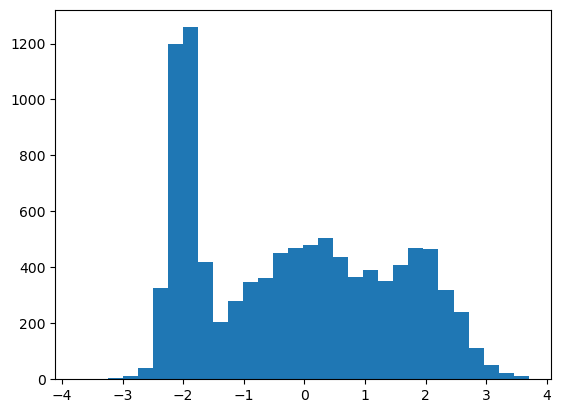

In [17]:
data  = gauss_mix.sample((10000,1))
plt.hist(data.cpu().detach().numpy(), bins=30)
plt.show()

In [18]:
class GaussianMixtureEM:
    def __init__(self, data, n_mix):
        """
        data: tensor (N,) o (N,1)
        n_mix: número de componentes
        """
        self.data = data if data.ndim == 2 else data.unsqueeze(1)
        self.N = self.data.shape[0]
        self.n_mix = n_mix

        # atributos que se llenarán al entrenar
        self.theta = None
        self.log_likelihood_history = []

    def __call__(self, tol=1e-6, max_iter=1000, seed=None):
        if seed is not None:
            torch.manual_seed(seed)

        # ----- inicialización -----
        p = torch.ones(self.n_mix) / self.n_mix
        mu = self.data[torch.randint(0, self.N, (self.n_mix,))].squeeze()
        sigma = torch.ones(self.n_mix)

        self.theta = {"p": [p], "mu": [mu], "sigma": [sigma]}
        self.log_likelihood_history = []

        ll_old = -torch.inf

        for k in range(max_iter):

            # ===== E-step =====
            dist = torch.distributions.Normal(mu, sigma)
            log_probs = dist.log_prob(self.data)           # (N,K)
            log_weighted = log_probs + torch.log(p)        # (N,K)

            log_gamma = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)
            gamma = torch.exp(log_gamma)

            # ===== M-step =====
            n_k = gamma.sum(dim=0)

            p_new = n_k / self.N
            mu_new = (gamma * self.data).sum(dim=0) / n_k
            var_new = (gamma * (self.data - mu_new)**2).sum(dim=0) / n_k
            sigma_new = torch.sqrt(var_new)

            # evitar problemas numéricos
            sigma_new = torch.clamp(sigma_new, min=1e-6)
            p_new = torch.clamp(p_new, min=1e-8)
            p_new = p_new / p_new.sum()

            # ===== log-likelihood (con parámetros nuevos) =====
            dist_new = torch.distributions.Normal(mu_new, sigma_new)
            log_probs_new = dist_new.log_prob(self.data)
            log_weighted_new = log_probs_new + torch.log(p_new)

            ll = torch.logsumexp(log_weighted_new, dim=1).sum()
            self.log_likelihood_history.append(ll.item())

            print(f"Iter {k}, loglik = {ll.item():.6f}")

            # ===== criterio de paro =====
            if torch.abs(ll - ll_old) < tol:
                print("Convergió")
                break

            ll_old = ll

            # actualizar parámetros
            p, mu, sigma = p_new, mu_new, sigma_new

            # guardar historial
            self.theta["p"].append(p)
            self.theta["mu"].append(mu)
            self.theta["sigma"].append(sigma)

        return self

    def plot_log_likelihood(self):
        plt.figure()
        plt.plot(self.log_likelihood_history)
        plt.xlabel("Iteración")
        plt.ylabel("Log-verosimilitud")
        plt.title("Convergencia EM")
        plt.grid()
        plt.show()

    def plot_density(self, bins=50, show_components=True):
        """
        Grafica el histograma de los datos junto con la densidad estimada.
        """

        # últimos parámetros estimados
        p = self.theta["p"][-1]
        mu = self.theta["mu"][-1]
        sigma = self.theta["sigma"][-1]

        data = self.data.squeeze()

        # grid para evaluar densidad
        x_min, x_max = data.min().item(), data.max().item()
        x = torch.linspace(x_min, x_max, 500)

        # densidad total
        density = torch.zeros_like(x)

        for j in range(self.n_mix):
            dist = torch.distributions.Normal(mu[j], sigma[j])
            density += p[j] * torch.exp(dist.log_prob(x))

        # ===== plot =====
        plt.figure()

        # histograma
        plt.hist(data.numpy(), bins=bins, density=True, alpha=0.5)

        # mezcla total
        plt.plot(x.numpy(), density.detach().numpy(), linewidth=2, label="Mixture")

        # componentes individuales
        if show_components:
            for j in range(self.n_mix):
                dist = torch.distributions.Normal(mu[j], sigma[j])
                comp_density = p[j] * torch.exp(dist.log_prob(x))
                plt.plot(x.numpy(), comp_density.detach().numpy(), linestyle="--")

        plt.title("Ajuste de Mezcla Gaussiana (EM)")
        plt.xlabel("x")
        plt.ylabel("Densidad")
        plt.legend()
        plt.grid()

        plt.show()

In [19]:
model = GaussianMixtureEM(data, n_mix=3)
model(tol=1e-10, seed=42)


Iter 0, loglik = -17425.400391
Iter 1, loglik = -17286.742188
Iter 2, loglik = -17134.039062
Iter 3, loglik = -16955.968750
Iter 4, loglik = -16759.935547
Iter 5, loglik = -16569.800781
Iter 6, loglik = -16418.925781
Iter 7, loglik = -16325.388672
Iter 8, loglik = -16278.359375
Iter 9, loglik = -16256.955078
Iter 10, loglik = -16246.930664
Iter 11, loglik = -16241.516602
Iter 12, loglik = -16237.814453
Iter 13, loglik = -16234.577148
Iter 14, loglik = -16231.221680
Iter 15, loglik = -16227.424805
Iter 16, loglik = -16222.959961
Iter 17, loglik = -16217.609375
Iter 18, loglik = -16211.143555
Iter 19, loglik = -16203.288086
Iter 20, loglik = -16193.744141
Iter 21, loglik = -16182.185547
Iter 22, loglik = -16168.323242
Iter 23, loglik = -16151.975586
Iter 24, loglik = -16133.208008
Iter 25, loglik = -16112.478516
Iter 26, loglik = -16090.755859
Iter 27, loglik = -16069.438477
Iter 28, loglik = -16050.050781
Iter 29, loglik = -16033.754883
Iter 30, loglik = -16020.989258
Iter 31, loglik = 

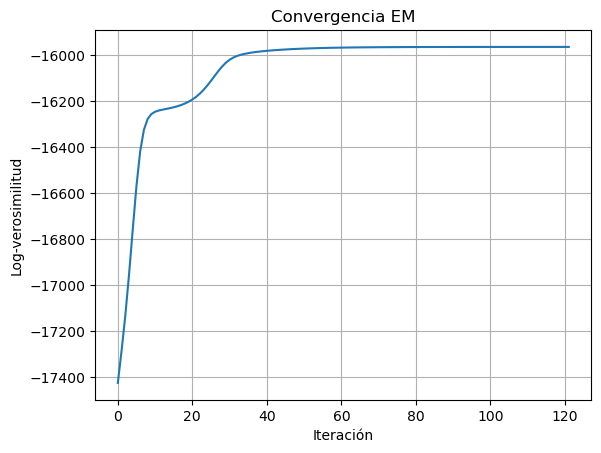

mu: tensor([ 2.0219,  0.0241, -2.0018])
sigma: tensor([0.5144, 1.0233, 0.1978])
p: tensor([0.1968, 0.5096, 0.2936])


In [20]:
model.plot_log_likelihood()

# parámetros finales
print("mu:", model.theta["mu"][-1])
print("sigma:", model.theta["sigma"][-1])
print("p:", model.theta["p"][-1])

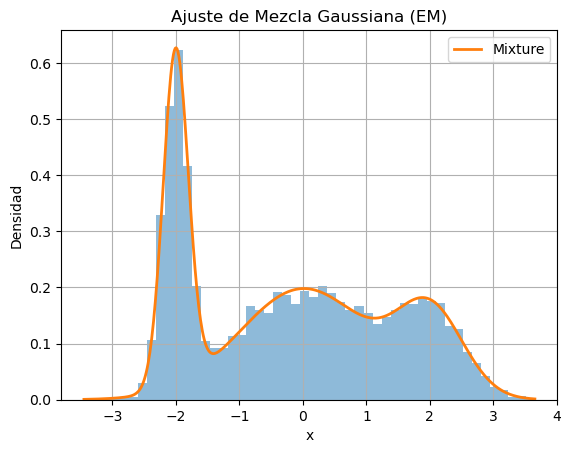

In [8]:
model.plot_density(show_components=False)

In [9]:
data_ins = pd.read_csv("data/claims_q12023.csv",sep=None, engine='python')
data_ins

,cust_age,policy_id,coverage_start_date,cust_region,sum_assured_group,ins_deductible,annual_prem,zip_code,insured_sex,edu_lvl,...,bodily_injuries,witnesses,police_report_avlbl,total_claim_amount,injury_claim,property_claim,vehicle_claim,car_brand,car_model,production_year
0,44,225016,08.09.2007,north,mid,2000,1007.48,342178,F,college,...,0,2,YES,74140,13480,13480,47180,BMW,X5,2022
1,56,316183,02.02.2016,north,mid,500,1080.60,506682,F,phd,...,2,3,NaN,56430,0,6270,50160,Honda,CRV,2021
2,28,174430,04.02.2020,east,mid,2000,1078.03,330854,M,high school,...,0,1,YES,53600,6700,6700,40200,Volkswagen,Jetta,2014
3,53,67527,27.01.2013,north,low,1000,1026.55,502272,F,college,...,0,0,NO,80960,14720,7360,58880,Accura,MDX,2007
4,47,259758,08.04.2015,east,mid,2000,1484.15,515656,F,associate,...,2,3,NaN,64100,12820,6410,44870,Dodge,RAM,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,53,477651,03.03.1998,west,low,2000,1394.54,348690,F,associate,...,2,1,NaN,47430,5270,5270,36890,Toyota,Camry,2007
996,32,265179,20.11.2013,east,high,2000,1255.11,516309,F,high school,...,1,3,NO,61270,5570,11140,44560,Subaru,Legacy,2006
997,29,182883,11.09.2013,west,low,1000,1521.28,510447,M,masters,...,1,2,YES,94560,7880,15760,70920,Jeep,Grand Cherokee,2002
998,56,438442,28.10.2009,west,mid,500,1040.67,516735,M,high school,...,0,2,NO,68040,15120,7560,45360,Subaru,Forrestor,2004


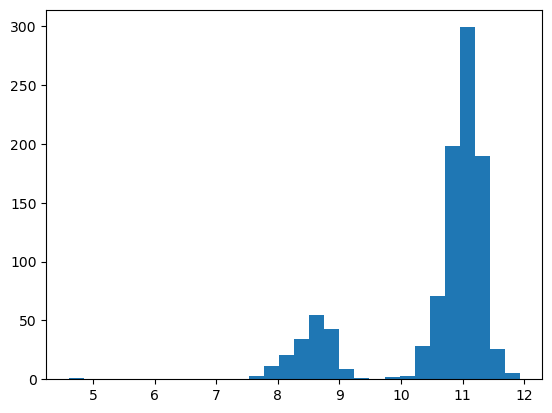

In [10]:
x = torch.tensor(data_ins["total_claim_amount"]).log()
plt.hist(x.cpu(), bins=30)
plt.show()

In [11]:
model_cm = GaussianMixtureEM(x, n_mix=2)
model_cm(tol=1e-10, seed=1997)

Iter 0, loglik = -1377.039551
Iter 1, loglik = -1209.534912
Iter 2, loglik = -858.950562
Iter 3, loglik = -767.977722
Iter 4, loglik = -746.154175
Iter 5, loglik = -736.492920
Iter 6, loglik = -729.177795
Iter 7, loglik = -721.400513
Iter 8, loglik = -711.245911
Iter 9, loglik = -698.174255
Iter 10, loglik = -684.639282
Iter 11, loglik = -675.884521
Iter 12, loglik = -673.523926
Iter 13, loglik = -673.295288
Iter 14, loglik = -673.284424
Iter 15, loglik = -673.284180
Iter 16, loglik = -673.284058
Iter 17, loglik = -673.284058
Convergió


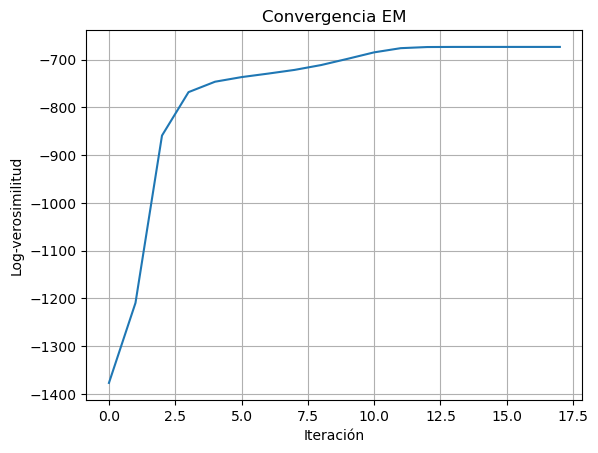

mu: tensor([ 8.5468, 11.0217])
sigma: tensor([0.4681, 0.2681])
p: tensor([0.1804, 0.8196])


In [12]:
model_cm.plot_log_likelihood()
# parámetros finales
print("mu:", model_cm.theta["mu"][-1])
print("sigma:", model_cm.theta["sigma"][-1])
print("p:", model_cm.theta["p"][-1])

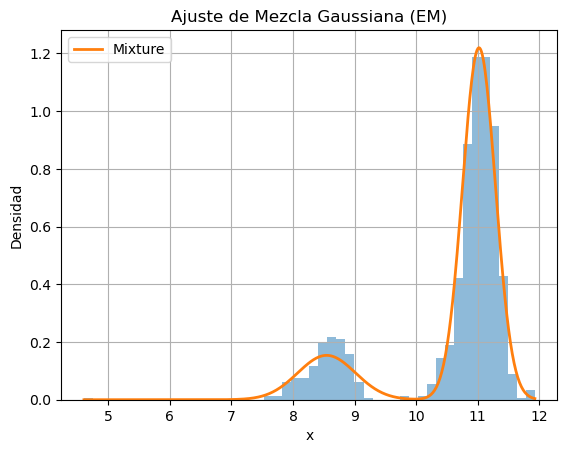

In [13]:
model_cm.plot_density(show_components=False)

In [3]:
class GaussianMixtureEMMultivariate:
    def __init__(self, data, n_mix):
        """
        data: tensor (N,D)
        n_mix: número de clusters
        """
        self.data = data if data.ndim == 2 else data.unsqueeze(1)
        self.N, self.D = self.data.shape
        self.K = n_mix

        self.theta = None
        self.log_likelihood_history = []
        self.gamma = None  # responsabilidades finales

    def __call__(self, tol=1e-6, max_iter=1000, seed=None):

        if seed is not None:
            torch.manual_seed(seed)

        # ===== inicialización =====
        p = torch.ones(self.K) / self.K

        # medias: (K, D)
        mu = self.data[torch.randint(0, self.N, (self.K,))]

        # covarianzas: (K, D, D)
        Sigma = torch.stack([torch.eye(self.D) for _ in range(self.K)])

        self.theta = {"p": [p], "mu": [mu], "Sigma": [Sigma]}
        self.log_likelihood_history = []

        ll_old = -torch.inf

        for it in range(max_iter):

            # ===== E-step =====
            dist = torch.distributions.MultivariateNormal(mu, Sigma)

            # (N, K)
            log_probs = dist.log_prob(self.data.unsqueeze(1))

            log_weighted = log_probs + torch.log(p)
            log_gamma = log_weighted - torch.logsumexp(log_weighted, dim=1, keepdim=True)
            gamma = torch.exp(log_gamma)

            # ===== M-step =====
            n_k = gamma.sum(dim=0)  # (K,)

            p_new = n_k / self.N

            # medias (K, D)
            mu_new = (gamma.unsqueeze(-1) * self.data.unsqueeze(1)).sum(dim=0) / n_k.unsqueeze(-1)

            # ===== covarianzas =====
            diff = self.data.unsqueeze(1) - mu_new.unsqueeze(0)  # (N, K, D)

            # producto externo → (N, K, D, D)
            outer = diff.unsqueeze(-1) * diff.unsqueeze(-2)

            # ponderación
            Sigma_new = (gamma.unsqueeze(-1).unsqueeze(-1) * outer).sum(dim=0) / n_k.view(self.K, 1, 1)

            # ===== estabilidad numérica =====
            eps = 1e-6
            eye = torch.eye(self.D, device=self.data.device).unsqueeze(0)
            Sigma_new = Sigma_new + eps * eye

            p_new = torch.clamp(p_new, min=1e-8)
            p_new = p_new / p_new.sum()

            # ===== log-likelihood =====
            dist_new = torch.distributions.MultivariateNormal(mu_new, Sigma_new)

            log_probs_new = dist_new.log_prob(self.data.unsqueeze(1))
            log_weighted_new = log_probs_new + torch.log(p_new)

            ll = torch.logsumexp(log_weighted_new, dim=1).sum()
            self.log_likelihood_history.append(ll.item())

            print(f"Iter {it}, loglik = {ll.item():.6f}")

            if torch.abs(ll - ll_old) < tol:
                print("Convergió")
                break

            ll_old = ll

            p, mu, Sigma = p_new, mu_new, Sigma_new

            self.theta["p"].append(p)
            self.theta["mu"].append(mu)
            self.theta["Sigma"].append(Sigma)

        self.gamma = gamma
        return self




    # ===== Predicciones =====
    def predict(self):
        return self.gamma.argmax(dim=1)

    def predict_proba(self):
        return self.gamma

    # ===== Visualización =====
    def plot_clusters(self):
        labels = self.predict()
        X = self.data

        if self.D == 1:
            plt.scatter(X[:, 0], torch.zeros_like(X[:, 0]), c=labels)
            plt.xlabel("x")
            plt.title("Clusters en 1D")

        elif self.D == 2:
            plt.scatter(X[:, 0], X[:, 1], c=labels)
            plt.xlabel("x1")
            plt.ylabel("x2")
            plt.title("Clusters en 2D")

        elif self.D == 3:
            fig = plt.figure()
            ax = fig.add_subplot(111, projection='3d')
            ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels)
            ax.set_xlabel("x1")
            ax.set_ylabel("x2")
            ax.set_zlabel("x3")
            ax.set_title("Clusters en 3D")

        else:
            print("Visualización solo soporta D=1,2,3")

        plt.show()

Iter 0, loglik = -773.320190
Iter 1, loglik = -761.382202
Iter 2, loglik = -754.034119
Iter 3, loglik = -748.988831
Iter 4, loglik = -744.157288
Iter 5, loglik = -737.776733
Iter 6, loglik = -728.988464
Iter 7, loglik = -714.129700
Iter 8, loglik = -693.399658
Iter 9, loglik = -688.424561
Iter 10, loglik = -688.420837
Iter 11, loglik = -688.420837
Convergió


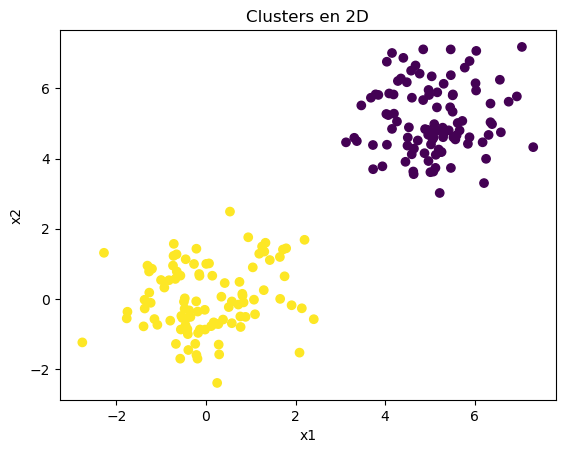

In [4]:
X1 = torch.randn(100, 2) + torch.tensor([0., 0.])
X2 = torch.randn(100, 2) + torch.tensor([5., 5.])
X = torch.cat([X1, X2], dim=0)

model = GaussianMixtureEMMultivariate(X, n_mix=2)
model()

model.plot_clusters()

In [5]:
model.predict_proba()

tensor([[3.1259e-12, 1.0000e+00],
        [3.2996e-12, 1.0000e+00],
        [2.1838e-13, 1.0000e+00],
        [3.5564e-11, 1.0000e+00],
        [2.5140e-07, 1.0000e+00],
        [4.0825e-07, 1.0000e+00],
        [4.6783e-12, 1.0000e+00],
        [5.2955e-14, 1.0000e+00],
        [3.1397e-17, 1.0000e+00],
        [1.5384e-14, 1.0000e+00],
        [4.0321e-13, 1.0000e+00],
        [7.9823e-11, 1.0000e+00],
        [3.3441e-15, 1.0000e+00],
        [1.5463e-16, 1.0000e+00],
        [2.1180e-10, 1.0000e+00],
        [2.6376e-06, 1.0000e+00],
        [3.5926e-14, 1.0000e+00],
        [9.9643e-11, 1.0000e+00],
        [3.8943e-12, 1.0000e+00],
        [7.4827e-09, 1.0000e+00],
        [1.8528e-17, 1.0000e+00],
        [6.3970e-12, 1.0000e+00],
        [1.1807e-19, 1.0000e+00],
        [3.3261e-11, 1.0000e+00],
        [2.5175e-15, 1.0000e+00],
        [3.3638e-15, 1.0000e+00],
        [5.0434e-17, 1.0000e+00],
        [2.0478e-13, 1.0000e+00],
        [1.3795e-08, 1.0000e+00],
        [2.275

In [7]:
model.theta["p"][-1]

tensor([0.5000, 0.5000])

In [8]:
model.theta["mu"][-1]

tensor([[5.0606, 5.1230],
        [0.0204, 0.0201]])

In [9]:
model.theta["Sigma"][-1]

tensor([[[0.7530, 0.0441],
         [0.0441, 0.9777]],

        [[1.0676, 0.1567],
         [0.1567, 0.9170]]])

In [11]:
fifa_20 = pd.read_csv('data/players_20.csv')
features = list(fifa_20.columns[fifa_20.dtypes=='int64'])[11:]
target = ['overall']

In [12]:
scaler_X = StandardScaler()
scaler_X.fit(np.array(fifa_20[features]))

def pre_data(df, scaler_X):

    X = df[features]
    y = np.array(df[target])

    X = scaler_X.transform(X)

    return X,y

X , y = pre_data(fifa_20, scaler_X)

pca = PCA()
pca.fit(X)
CPX = pca.transform(X)

C:\Users\Academica\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


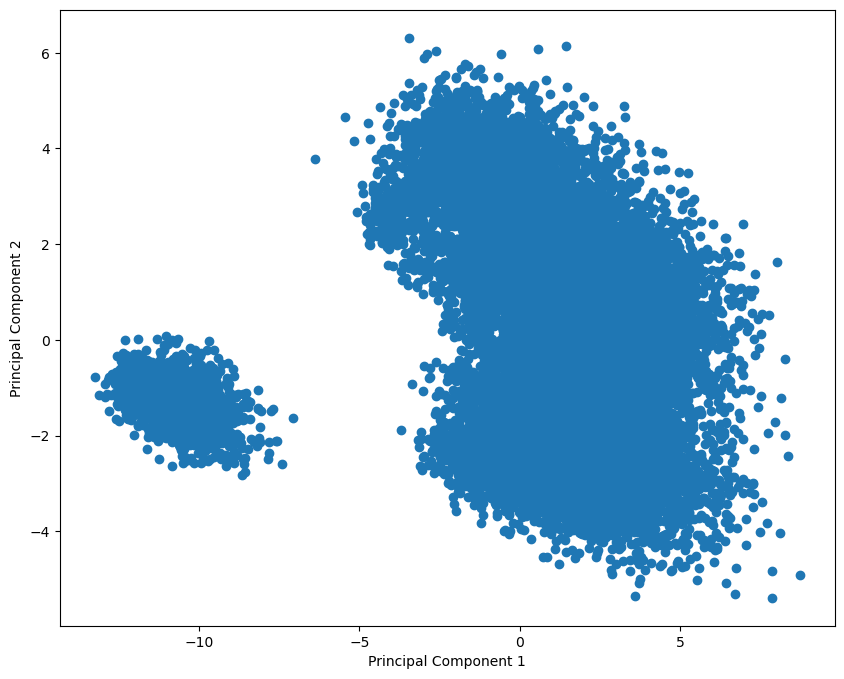

In [13]:
plt.figure(figsize=(10,8))
plt.scatter(CPX[:,0],CPX[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.plot()
plt.show()

Iter 0, loglik = -87786.703125
Iter 1, loglik = -87055.593750
Iter 2, loglik = -86640.296875
Iter 3, loglik = -86240.914062
Iter 4, loglik = -85872.265625
Iter 5, loglik = -85551.859375
Iter 6, loglik = -85290.867188
Iter 7, loglik = -85093.187500
Iter 8, loglik = -84953.031250
Iter 9, loglik = -84856.632812
Iter 10, loglik = -84788.312500
Iter 11, loglik = -84735.218750
Iter 12, loglik = -84687.796875
Iter 13, loglik = -84637.234375
Iter 14, loglik = -84570.351562
Iter 15, loglik = -84454.750000
Iter 16, loglik = -84178.578125
Iter 17, loglik = -83300.953125
Iter 18, loglik = -81638.031250
Iter 19, loglik = -81629.812500
Iter 20, loglik = -81629.804688
Iter 21, loglik = -81629.812500
Iter 22, loglik = -81629.812500
Convergió


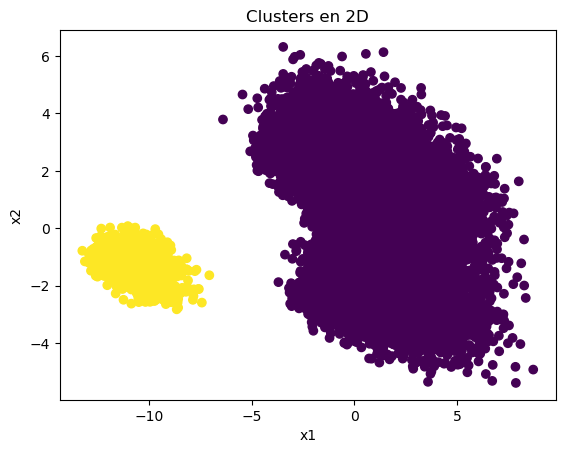

In [14]:
pca_data_fifa = torch.Tensor(CPX[:,:2])
gmm_fifa = GaussianMixtureEMMultivariate(pca_data_fifa, n_mix=2)
gmm_fifa()
gmm_fifa.plot_clusters()

In [15]:
gmm_fifa.theta["p"][-1]

tensor([0.8886, 0.1114])

In [16]:
gmm_fifa.theta["mu"][-1]

tensor([[  1.3379,   0.1597],
        [-10.6732,  -1.2739]])

In [17]:
gmm_fifa.theta["Sigma"][-1]

tensor([[[ 4.8344, -1.8923],
         [-1.8923,  5.3551]],

        [[ 0.9676, -0.2045],
         [-0.2045,  0.2123]]])

Iter 0, loglik = -84433.929688
Iter 1, loglik = -81966.210938
Iter 2, loglik = -81487.398438
Iter 3, loglik = -81017.781250
Iter 4, loglik = -80117.656250
Iter 5, loglik = -79284.492188
Iter 6, loglik = -79267.671875
Iter 7, loglik = -79254.156250
Iter 8, loglik = -79241.671875
Iter 9, loglik = -79229.906250
Iter 10, loglik = -79218.835938
Iter 11, loglik = -79208.507812
Iter 12, loglik = -79199.015625
Iter 13, loglik = -79190.421875
Iter 14, loglik = -79182.718750
Iter 15, loglik = -79175.906250
Iter 16, loglik = -79169.906250
Iter 17, loglik = -79164.640625
Iter 18, loglik = -79160.046875
Iter 19, loglik = -79156.007812
Iter 20, loglik = -79152.460938
Iter 21, loglik = -79149.335938
Iter 22, loglik = -79146.546875
Iter 23, loglik = -79144.031250
Iter 24, loglik = -79141.742188
Iter 25, loglik = -79139.640625
Iter 26, loglik = -79137.671875
Iter 27, loglik = -79135.859375
Iter 28, loglik = -79134.117188
Iter 29, loglik = -79132.468750
Iter 30, loglik = -79130.882812
Iter 31, loglik = 

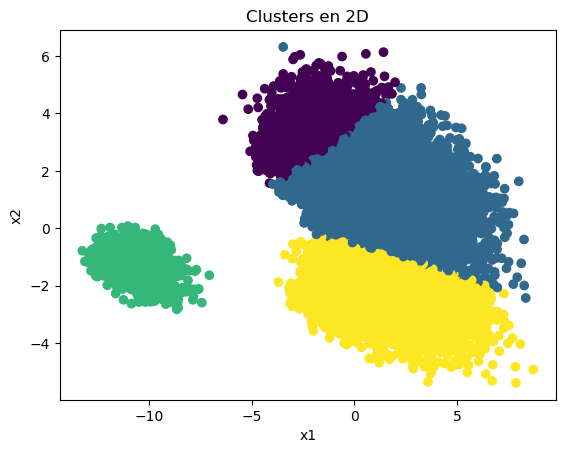

In [18]:
pca_data_fifa = torch.Tensor(CPX[:,:2])
gmm_fifa = GaussianMixtureEMMultivariate(pca_data_fifa, n_mix=4)
gmm_fifa(seed=1)
gmm_fifa.plot_clusters()

In [20]:
fifa_20['cluster'] = gmm_fifa.predict()
fifa_20[['short_name','cluster','player_positions', 'overall']].query('cluster==0')

,short_name,cluster,player_positions,overall
11,K. Koulibaly,0,CB,89
77,N. Süle,0,CB,85
83,J. Giménez,0,CB,85
90,K. Manolas,0,CB,85
156,Felipe,0,CB,84
...,...,...,...,...
18256,S. Cartwright,0,"CB, RB",48
18260,A. De Angelis,0,"CDM, CM",48
18262,S. Callan,0,"CB, RB",48
18273,Shao Shuai,0,CB,48


In [21]:
fifa_20[['short_name','cluster','player_positions', 'overall']].query('cluster==1')

,short_name,cluster,player_positions,overall
5,K. De Bruyne,1,"CAM, CM",91
7,V. van Dijk,1,CB,90
8,L. Modrić,1,CM,90
15,N. Kanté,1,"CDM, CM",89
16,G. Chiellini,1,CB,89
...,...,...,...,...
18270,M. Sagaf,1,CM,48
18271,E. Tweed,1,CM,48
18275,Zhang Wei,1,CM,48
18276,Wang Haijian,1,CM,48


In [22]:
fifa_20[['short_name','cluster','player_positions']].query('cluster==2')

,short_name,cluster,player_positions
3,J. Oblak,2,GK
6,M. ter Stegen,2,GK
13,Alisson,2,GK
14,De Gea,2,GK
25,Ederson,2,GK
...,...,...,...
18231,P. Królczyk,2,GK
18239,V. Storsve,2,GK
18251,G. Sykes-Kenworthy,2,GK
18259,H. Sveijer,2,GK


In [23]:
fifa_20[['short_name','cluster','player_positions']].query('cluster==3')

,short_name,cluster,player_positions
0,L. Messi,3,"RW, CF, ST"
1,Cristiano Ronaldo,3,"ST, LW"
2,Neymar Jr,3,"LW, CAM"
4,E. Hazard,3,"LW, CF"
9,M. Salah,3,"RW, ST"
...,...,...,...
18257,Song Min Kyu,3,LW
18258,L. Collins,3,CM
18261,H. Shirai,3,ST
18266,Wang Peng,3,CAM


In [26]:
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS
import jax
import jax.random as random
numpyro.set_host_device_count(3)

In [27]:
def gmm_multivariante_flexible(data, num_components, tipo="completa"):
    """
    Modelo de Mezcla Gaussiana Bayesiano en NumPyro con covarianza configurable.

    Parámetros:
    -----------
    data : jnp.ndarray
        Matriz de datos con dimensiones (N, num_features).
    num_components : int
        Número de clústeres o componentes Gaussianas.
    tipo : str
        Tipo de covarianza: 'esferica', 'diagonal' o 'completa'.
    """
    num_samples, num_features = data.shape

    # 1. Prior para los pesos de mezcla (Distribución Dirichlet)
    mixing_weights = numpyro.sample("mixing_weights", dist.Dirichlet(jnp.ones(num_components)))

    # 2. Priors para las medias de cada componente (num_components x num_features)
    with numpyro.plate("components", num_components):
        locs = numpyro.sample("locs", dist.Normal(jnp.zeros(num_features), 10.0).to_event(1))

        # 3. Construcción de la covarianza según el parámetro 'tipo'
        if tipo == "esferica":
            # Una sola varianza común para todas las dimensiones del componente
            sigma_global = numpyro.sample("sigma_global", dist.HalfNormal(2.0))
            # Creamos una matriz identidad escalada: (num_features x num_features)
            L_cov = sigma_global[..., None, None] * jnp.eye(num_features)

        elif tipo == "diagonal":
            # Una varianza independiente por cada dimensión del componente
            sigmas_diagonales = numpyro.sample("sigmas_diagonales", dist.HalfNormal(jnp.ones(num_features) * 2.0).to_event(1))
            # Convertimos el vector de sigmas en una matriz diagonal L
            L_cov = jnp.vectorize(jnp.diag, signature='(m)->(m,m)')(sigmas_diagonales)

        elif tipo == "completa":
            # Desviaciones estándar para cada dimensión
            sigmas = numpyro.sample("sigmas", dist.HalfNormal(jnp.ones(num_features) * 2.0).to_event(1))
            # Matriz de correlación LKJ Cholesky
            corr_cholesky = numpyro.sample("corr_cholesky", dist.LKJCholesky(num_features, concentration=1.0))
            # Combinamos escalas y correlaciones: L = diag(sigmas) @ corr_cholesky
            L_cov = jnp.expand_dims(sigmas, -1) * corr_cholesky

        else:
            raise ValueError("El parámetro 'tipo' debe ser: 'esferica', 'diagonal' o 'completa'")

    # 4. Distribución de mezcla marginalizada
    # Pasamos L_cov a scale_tril para asegurar estabilidad numérica y velocidad
    mixture_dist = dist.MixtureSameFamily(
        mixing_distribution=dist.Categorical(probs=mixing_weights),
        component_distribution=dist.MultivariateNormal(loc=locs, scale_tril=L_cov)
    )

    # 5. Verosimilitud de las observaciones
    with numpyro.plate("data", num_samples):
        numpyro.sample("obs", mixture_dist, obs=data)

In [31]:
rng_key = jax.random.PRNGKey(42)
num_clusters = 4

X = jnp.array(pca_data_fifa)

# Ejemplo de ejecución con covarianza diagonal
nuts_kernel = NUTS(gmm_multivariante_flexible)
mcmc = MCMC(nuts_kernel, num_warmup=500, num_samples=1000, num_chains=3, chain_method="parallel")

In [57]:
mcmc.run(rng_key, data=X, num_components=num_clusters, tipo="esferica")
mcmc.print_summary()

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]

  0%|          | 0/1500 [00:00<?, ?it/s]


                       mean       std    median      5.0%     95.0%     n_eff     r_hat
        locs[0,0]     -7.22      4.88    -10.66    -10.71     -0.27      1.50    110.77
        locs[0,1]     -1.61      0.47     -1.28     -2.30     -1.24      1.50     21.99
        locs[1,0]     -3.21      5.42     -1.00    -10.69      2.07      1.50    212.08
        locs[1,1]      0.26      1.86     -0.83     -1.30      2.90      1.50     78.63
        locs[2,0]     -0.20      0.72     -0.32     -1.07      0.79      1.51     10.76
        locs[2,1]      0.97      2.31      2.31     -2.30      2.91      1.50     60.00
        locs[3,0]      0.91      2.00      2.30     -1.97      2.38      1.50     48.12
        locs[3,1]      0.75      1.78     -0.49     -0.55      3.29      1.50     69.95
mixing_weights[0]      0.10      0.02      0.11      0.06      0.12      1.53      6.86
mixing_weights[1]      0.32      0.23      0.21      0.11      0.65      1.50     49.80
mixing_weights[2]      0.13    

In [58]:
samples = mcmc.get_samples()

In [59]:
samples["locs"].shape

(3000, 4, 2)

In [60]:
def predecir_clusters(data, posterior_samples, tipo="completa"):
    """
    Calcula las asignaciones de clústeres promediando sobre las muestras de la posterior.

    Parámetros:
    -----------
    data : jnp.ndarray
        Datos a clasificar (pueden ser los mismos de entrenamiento o datos nuevos). Shape: (N, D)
    posterior_samples : dict
        El diccionario devuelto por `mcmc.get_samples()`.
    tipo : str
        El tipo de covarianza utilizado en el modelo ('esferica', 'diagonal', 'completa').
    """
    # Extraer parámetros de la posterior
    weights = posterior_samples["mixing_weights"]  # (Smuestras, K)
    locs = posterior_samples["locs"]              # (Smuestras, K, D)

    num_samples_mcmc = weights.shape[0]
    num_components = weights.shape[1]
    num_data, num_features = data.shape

    # 1. Reconstruir L_cov para todas las muestras MCMC según el 'tipo'
    if tipo == "esferica":
        sigmas = posterior_samples["sigma_global"] # (Smuestras, K)
        # Identidad expandida para JAX
        I = jnp.eye(num_features)
        L_cov = sigmas[..., None, None] * I  # (Smuestras, K, D, D)

    elif tipo == "diagonal":
        sigmas = posterior_samples["sigmas_diagonales"] # (Smuestras, K, D)
        L_cov = jnp.vectorize(jnp.diag, signature='(m)->(m,m)')(sigmas)

    elif tipo == "completa":
        sigmas = posterior_samples["sigmas"]           # (Smuestras, K, D)
        corr_cholesky = posterior_samples["corr_cholesky"] # (Smuestras, K, D, D)
        L_cov = jnp.expand_dims(sigmas, -1) * corr_cholesky

    # 2. Definir la función para calcular log-probabilidades por componente para UNA muestra MCMC
    def calcular_log_prob_por_muestra(w, l, L):
        # Creamos la distribución multivariada para los K componentes
        comp_dist = dist.MultivariateNormal(loc=l, scale_tril=L)

        # Evaluamos el log-pdf de CADA dato en CADA uno de los K componentes
        # Hacemos broadcasting de data (N, 1, D) contra comp_dist (K, D)
        log_prob_componentes = comp_dist.log_prob(data[:, None, :]) # Shape: (N, K)

        # Sumamos el logaritmo del peso del clúster: log(p(x|k)) + log(pi_k)
        log_unnormalized_posterior = log_prob_componentes + jnp.log(w)

        # Normalizamos usando el truco log-sum-exp para obtener las probabilidades (Bayes)
        log_probs_normalizadas = log_unnormalized_posterior - jax.scipy.special.logsumexp(log_unnormalized_posterior, axis=-1, keepdims=True)
        return jnp.exp(log_probs_normalizadas) # Retorna probabilidades suaves (N, K)

    # 3. Vectorizar el cálculo sobre todas las muestras del MCMC usando vmap de JAX
    vmap_calcular = jax.vmap(calcular_log_prob_por_muestra, in_axes=(0, 0, 0))

    # Matriz de probabilidades para cada muestra MCMC. Shape: (Smuestras, N, K)
    probabilidades_todas_muestras = vmap_calcular(weights, locs, L_cov)

    # 4. Promediar las probabilidades a través de la posterior bayesiana (Marginalización del MCMC)
    probabilidades_promedio = jnp.mean(probabilidades_todas_muestras, axis=0) # Shape: (N, K)

    # 5. Asignación dura (Hard assignment): Elegir el clúster con mayor probabilidad
    clusters_predichos = jnp.argmax(probabilidades_promedio, axis=-1) # Shape: (N,)

    return probabilidades_promedio, clusters_predichos

In [61]:
muestras_posterior = mcmc.get_samples()

# 2. Calcular las predicciones (pueden ser los mismos datos o datos nuevos 'X_new')
probabilidades, cluster_final = predecir_clusters(
    data=X,
    posterior_samples=muestras_posterior,
    tipo="esferica" # Asegúrate de usar el mismo tipo con el que entrenaste
)

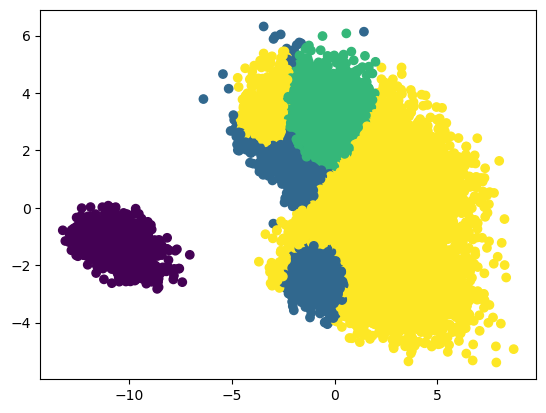

In [62]:
plt.scatter(X[:,0], X[:,1], c=cluster_final)
plt.show()

In [51]:
cluster_final[cluster_final==2].shape

(3447,)

In [68]:
fifa_20['cluster2'] = cluster_final


In [70]:
fifa_20[['short_name','cluster2','player_positions', 'overall']].query('cluster2==0')

,short_name,cluster2,player_positions,overall
3,J. Oblak,0,GK,91
6,M. ter Stegen,0,GK,90
13,Alisson,0,GK,89
14,De Gea,0,GK,89
25,Ederson,0,GK,88
...,...,...,...,...
18231,P. Królczyk,0,GK,49
18239,V. Storsve,0,GK,48
18251,G. Sykes-Kenworthy,0,GK,48
18259,H. Sveijer,0,GK,48


In [71]:
fifa_20[['short_name','cluster2','player_positions', 'overall']].query('cluster2==1')

,short_name,cluster2,player_positions,overall
11,K. Koulibaly,1,CB,89
1418,Y. Gómez Andrade,1,CB,76
1467,S. Bamba,1,CB,76
1888,W. Morgan,1,CB,75
2376,G. Ferrari,1,CB,74
...,...,...,...,...
18273,Shao Shuai,1,CB,48
18274,Xiao Mingjie,1,CB,48
18275,Zhang Wei,1,CM,48
18276,Wang Haijian,1,CM,48


In [72]:
fifa_20[['short_name','cluster2','player_positions', 'overall']].query('cluster2==2')

,short_name,cluster2,player_positions,overall
77,N. Süle,2,CB,85
83,J. Giménez,2,CB,85
90,K. Manolas,2,CB,85
156,Felipe,2,CB,84
158,A. Romagnoli,2,CB,83
...,...,...,...,...
17327,Jin Qiang,2,CDM,55
17346,N. Hunt,2,"RB, CB, LB",55
17448,T. Campulka,2,"CDM, CM",54
17601,D. Mistrafovic,2,CDM,53


In [73]:
fifa_20[['short_name','cluster2','player_positions', 'overall']].query('cluster2==3')

,short_name,cluster2,player_positions,overall
0,L. Messi,3,"RW, CF, ST",94
1,Cristiano Ronaldo,3,"ST, LW",93
2,Neymar Jr,3,"LW, CAM",92
3,J. Oblak,0,GK,91
4,E. Hazard,3,"LW, CF",91
...,...,...,...,...
18273,Shao Shuai,1,CB,48
18274,Xiao Mingjie,1,CB,48
18275,Zhang Wei,1,CM,48
18276,Wang Haijian,1,CM,48
